In [7]:
import torch
import torchvision
from torchvision.transforms import ToTensor
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

In [8]:
print(torch.__version__,torch.cuda.is_available())
print(torch.cuda.get_device_name(0)if torch.cuda.is_available() else "cpu")

2.7.1+cu118 True
NVIDIA GeForce RTX 3060 Laptop GPU


In [9]:
#准备数据集
CIFAR_MEAN = (0.4914,0.4822,0.4465)
CIFAR_STD = (0.2470,0.2435,0.2616)
transform_train = transforms.Compose([
    transforms.RandomCrop(32,padding =4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN,CIFAR_STD),
])
transform_test =transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN,CIFAR_STD),
])
train_data =torchvision.datasets.CIFAR10(root = '../dataset',train = True,transform =transform_train)
test_data =torchvision.datasets.CIFAR10(root = '../dataset',train = False,transform =transform_test)
train_dataloader = DataLoader(train_data,batch_size=64,shuffle = True,num_workers = 0)
test_dataloader = DataLoader(test_data,batch_size=64,shuffle = True,num_workers = 0)

print("训练集的长度为：{}".format(len(train_data)))
print("测试集的长度为：{}".format(len(test_data)))
imgs,target = train_data[0]
print(imgs.shape,target)
print(type(train_data.transform))

训练集的长度为：50000
测试集的长度为：10000
torch.Size([3, 32, 32]) 6
<class 'torchvision.transforms.transforms.Compose'>


In [10]:
class Fan(torch.nn.Module):
    def __init__(self):
        super(Fan,self).__init__()#Fan,self可以省略，这样不容易错
        self.Cheng =nn.Sequential(
            #将单块换成三块
            #块1
            nn.Conv2d(3,64,3,padding = 1),nn.BatchNorm2d(64),nn.ReLU(),
            nn.Conv2d(64,64,3,padding = 1),nn.BatchNorm2d(64),nn.ReLU(),
            nn.MaxPool2d(2),
            #块2
            nn.Conv2d(64,128,3,padding =1 ),nn.BatchNorm2d(128),nn.ReLU(),
            nn.Conv2d(128,128,3,padding =1 ),nn.BatchNorm2d(128),nn.ReLU(),
            nn.MaxPool2d(2),
            #块3
            nn.Conv2d(128,256,3,padding =1 ),nn.BatchNorm2d(256),nn.ReLU(),
            nn.MaxPool2d(2),

        )
        self.classifier = nn.Linear(256*4*4,10)

    def forward(self,x):
        x = self.classifier(torch.flatten(self.Cheng(x),1))
        return x


loader = DataLoader(train_data,batch_size = 64,shuffle=True)
imgs,targets =next(iter(loader))
print("输入：",imgs.shape)
print("输出：",Fan()(imgs).shape)

输入： torch.Size([64, 3, 32, 32])
输出： torch.Size([64, 10])


epoch 1 | loss:1.8311 | acc52.32%
epoch 2 | loss:1.2166 | acc62.02%
epoch 3 | loss:0.9668 | acc68.33%
epoch 4 | loss:0.8036 | acc72.90%
epoch 5 | loss:0.6990 | acc76.54%
epoch 6 | loss:0.6190 | acc77.59%
epoch 7 | loss:0.5608 | acc79.27%
epoch 8 | loss:0.5198 | acc79.73%
epoch 9 | loss:0.4820 | acc80.61%
epoch10 | loss:0.4465 | acc80.87%
epoch11 | loss:0.4173 | acc81.34%
epoch12 | loss:0.3986 | acc81.70%
epoch13 | loss:0.3740 | acc83.15%
epoch14 | loss:0.3535 | acc83.81%
epoch15 | loss:0.3315 | acc83.26%
epoch16 | loss:0.3156 | acc84.67%
epoch17 | loss:0.3017 | acc84.26%
epoch18 | loss:0.2826 | acc84.12%
epoch19 | loss:0.2716 | acc84.40%
epoch20 | loss:0.2558 | acc85.90%
epoch21 | loss:0.2466 | acc85.30%
epoch22 | loss:0.2321 | acc85.16%
epoch23 | loss:0.2199 | acc85.64%
epoch24 | loss:0.2085 | acc86.05%
epoch25 | loss:0.1994 | acc86.14%
epoch26 | loss:0.1852 | acc85.99%
epoch27 | loss:0.1766 | acc85.85%
epoch28 | loss:0.1697 | acc86.27%
epoch29 | loss:0.1559 | acc86.68%
epoch30 | loss

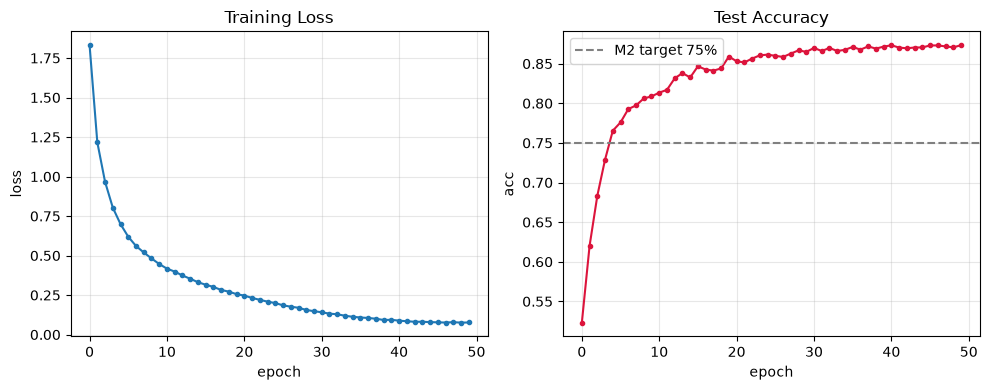

In [11]:
device = 'cuda'if torch.cuda.is_available() else 'cpu'
model = Fan().to(device)#将模型使用GPU
optimizer = torch.optim.SGD(model.parameters(),lr =0.01,momentum = 0.9)#使用优化器，确定学习率，momentum是什么
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=50)
hao_loss = nn.CrossEntropyLoss()#确定损失函数

best_acc = 0
losses,accs = [],[]
for epoch in range(50):
    model.train()#这一行干啥
    total_loss =0
    for imgs,targets in train_dataloader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        loss = hao_loss(model(imgs),targets)
        loss.backward()
        optimizer.step()
        total_loss = total_loss + loss.item()

    #评估
    correct = 0
    with torch.no_grad():
        for imgs,targets in test_dataloader:
            imgs,targets = imgs.to(device),targets.to(device)
            correct += (model(imgs).argmax(1) == targets).sum().item()
    acc = correct/len(test_data)
    print(f"epoch{epoch+1:2d} | loss:{total_loss/len(train_dataloader):.4f} | acc{acc:.2%}")#?
    losses.append(total_loss/len(train_dataloader))
    accs.append(acc)
    scheduler.step()

    if acc > best_acc:
        best_acc =acc
    torch.save(model.state_dict(),"best.pth")
print(f"\n最佳测试精度:{best_acc:.2%}")


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, marker='o', markersize=3)
plt.title("Training Loss"); plt.xlabel("epoch"); plt.ylabel("loss")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(accs, marker='o', markersize=3, color='crimson')
plt.axhline(y=0.75, color='gray', linestyle='--', label='M2 target 75%')
plt.title("Test Accuracy"); plt.xlabel("epoch"); plt.ylabel("acc")
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
